# Predictive Models for Fetal Health

This notebook implements the full project pipeline: data loading, EDA, data cleaning, preprocessing, model training, evaluation, and saving artifacts. It follows the project brief requirements and is ready to run.

Dataset: `fetalhealth.csv` (must be placed in `/mnt/data/`)


## Objectives and Expected Outcomes

**Objectives**

1. Develop classification models to predict fetal health (1=Normal, 2=Suspect, 3=Pathological).
2. Evaluate models using appropriate metrics and select the best-performing model.
3. Produce interpretability outputs (feature importance) and saved artifacts for deployment.

**Expected Outcomes**

- Cleaned dataset and documented data-preparation steps.
- Trained models with evaluation reports and visualizations.
- Saved best model and scaler.

## Performance Metrics

We will use the following classification metrics (measured on the holdout test set):

1. **Accuracy** — overall correctness of predictions.
2. **Recall (Sensitivity)** — especially important for class 3 (Pathological) to minimise false negatives.
3. **Precision** — to measure false positives.

Additionally, we report **Weighted F1 Score** to balance precision and recall across imbalanced classes.

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# plotting settings
sns.set(style='whitegrid')


In [160]:
df = pd.read_csv(r'C:\Users\agura\Downloads\Pandas\fetalhealth.csv')
print(df.head())
print('Dataset shape:', df.shape)


   baseline value  accelerations  fetal_movement  uterine_contractions  \
0             120          0.000             0.0                 0.000   
1             132          0.006             0.0                 0.006   
2             133          0.003             0.0                 0.008   
3             134          0.003             0.0                 0.008   
4             132          0.007             0.0                 0.008   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0                0.000                   0.0                       0.0   
1                0.003                   0.0                       0.0   
2                0.003                   0.0                       0.0   
3                0.003                   0.0                       0.0   
4                0.000                   0.0                       0.0   

   abnormal_short_term_variability  mean_value_of_short_term_variability  \
0                               73

In [161]:
print('\nData types:')
print(df.dtypes)


Data types:
baseline value                                              int64
accelerations                                             float64
fetal_movement                                            float64
uterine_contractions                                      float64
light_decelerations                                       float64
severe_decelerations                                      float64
prolongued_decelerations                                  float64
abnormal_short_term_variability                             int64
mean_value_of_short_term_variability                      float64
percentage_of_time_with_abnormal_long_term_variability      int64
mean_value_of_long_term_variability                       float64
histogram_width                                             int64
histogram_min                                               int64
histogram_max                                               int64
histogram_number_of_peaks                                   int

In [162]:
print('\nMissing values per column:')
print(df.isnull().sum())


Missing values per column:
baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mo

In [163]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
print('\nDuplicate rows after removal:', df.duplicated().sum())




Duplicate rows after removal: 0


In [164]:
print("\nDATA FORMAT CHECK:")
print(f"Non-numeric columns: {df.select_dtypes(exclude=[np.number]).columns.tolist()}")



DATA FORMAT CHECK:
Non-numeric columns: []


In [165]:
print("\nNEGATIVE VALUES CHECK:")
negative_cols = []
for col in df.select_dtypes(include=[np.number]).columns:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        negative_cols.append((col, neg_count))
        print(f"Column '{col}': {neg_count} negative values")


NEGATIVE VALUES CHECK:
Column 'histogram_tendency': 165 negative values


In [166]:
print("\nTARGET VARIABLE DISTRIBUTION:")
print(f"Fetal Health Classes:\n{df['fetal_health'].value_counts().sort_index()}")
print(f"\nClass Distribution (%):\n{df['fetal_health'].value_counts(normalize=True).sort_index() * 100}")


TARGET VARIABLE DISTRIBUTION:
Fetal Health Classes:
fetal_health
1    1646
2     292
3     175
Name: count, dtype: int64

Class Distribution (%):
fetal_health
1    77.898722
2    13.819214
3     8.282063
Name: proportion, dtype: float64


In [167]:
print("\nOUTLIER CHECK (using IQR method on sample features):")
key_features = ['baseline value', 'accelerations', 'severe_decelerations']
outlier_summary = {}
for col in key_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    outlier_summary[col] = outliers
    print(f"{col}: {outliers} potential outliers")


OUTLIER CHECK (using IQR method on sample features):
baseline value: 0 potential outliers
accelerations: 14 potential outliers
severe_decelerations: 7 potential outliers


In [168]:
print("\nSTATISTICAL SUMMARY:")
print(df.describe())


STATISTICAL SUMMARY:
       baseline value  accelerations  fetal_movement  uterine_contractions  \
count     2113.000000    2113.000000     2113.000000           2113.000000   
mean       133.304780       0.003188        0.009517              0.004387   
std          9.837451       0.003871        0.046804              0.002941   
min        106.000000       0.000000        0.000000              0.000000   
25%        126.000000       0.000000        0.000000              0.002000   
50%        133.000000       0.002000        0.000000              0.005000   
75%        140.000000       0.006000        0.003000              0.007000   
max        160.000000       0.019000        0.481000              0.015000   

       light_decelerations  severe_decelerations  prolongued_decelerations  \
count          2113.000000           2113.000000               2113.000000   
mean              0.001901              0.000003                  0.000159   
std               0.002966              0

In [169]:
print("\nCATEGORICAL FEATURES CHECK:")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols if categorical_cols else 'None'}")


CATEGORICAL FEATURES CHECK:
Categorical columns: None


In [170]:
print(f"\nCleaned: {df.shape}")


Cleaned: (2113, 22)


EXPLORATORY DATA ANALYSIS & VISUALIZATION

In [171]:
X = df.drop('fetal_health', axis=1)
y = df['fetal_health']

In [172]:
class_counts = df['fetal_health'].value_counts().sort_index()
print('\nClass Distribution (1=Normal, 2=Suspect, 3=Pathological):')
print(class_counts)


Class Distribution (1=Normal, 2=Suspect, 3=Pathological):
fetal_health
1    1646
2     292
3     175
Name: count, dtype: int64


In [173]:
print('\nPercentage Distribution:')
percentages = (class_counts / len(df) * 100).round(2)
for class_num, pct in percentages.items():
    class_labels = {1: 'Normal', 2: 'Suspect', 3: 'Pathological'}
    print(f"  Class {class_num} ({class_labels[class_num]}): {pct}%")



Percentage Distribution:
  Class 1 (Normal): 77.9%
  Class 2 (Suspect): 13.82%
  Class 3 (Pathological): 8.28%


C:\Users\agura\AppData\Local\Temp\ipykernel_12532\1209923756.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fetal_health', data=df, palette='Set2')


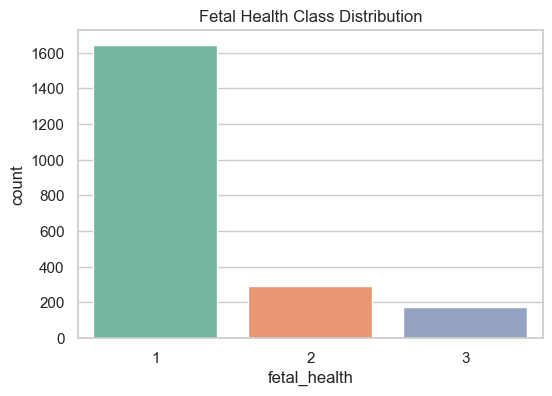

In [174]:
plt.figure(figsize=(6,4))
sns.countplot(x='fetal_health', data=df, palette='Set2')
plt.title('Fetal Health Class Distribution')
plt.xlabel('fetal_health')
plt.show()

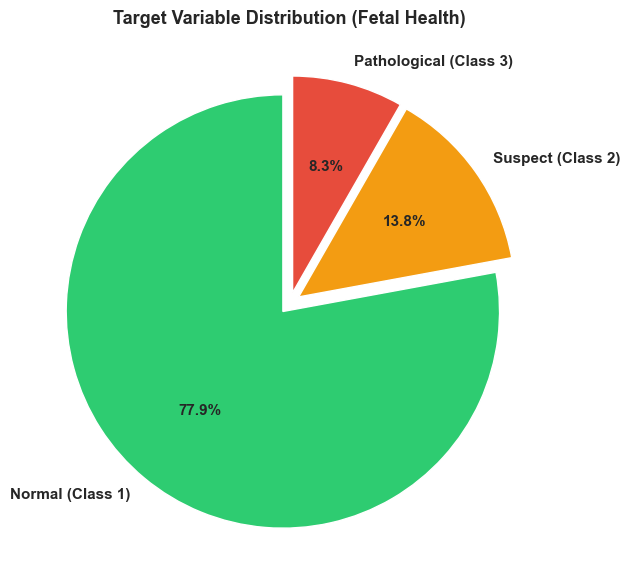

In [175]:
plt.figure(figsize=(8, 6))
target_counts = df['fetal_health'].value_counts().sort_index()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
labels = ['Normal (Class 1)', 'Suspect (Class 2)', 'Pathological (Class 3)']
explode = (0.05, 0.05, 0.05)

plt.pie(target_counts, labels=labels, colors=colors, autopct='%1.1f%%',
        explode=explode, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
plt.title('Target Variable Distribution (Fetal Health)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

,count,mean,std,min,25%,50%,75%,max
baseline value,2113.0,133.304780,9.837451,106.0,126.000,133.000,140.000,160.000
accelerations,2113.0,0.003188,0.003871,0.0,0.000,0.002,0.006,0.019
fetal_movement,2113.0,0.009517,0.046804,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2113.0,0.004387,0.002941,0.0,0.002,0.005,0.007,0.015
light_decelerations,2113.0,0.001901,0.002966,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2113.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2113.0,0.000159,0.000592,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2113.0,46.993848,17.177782,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2113.0,1.335021,0.884368,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2113.0,9.795078,18.337073,0.0,0.000,0.000,11.000,91.000


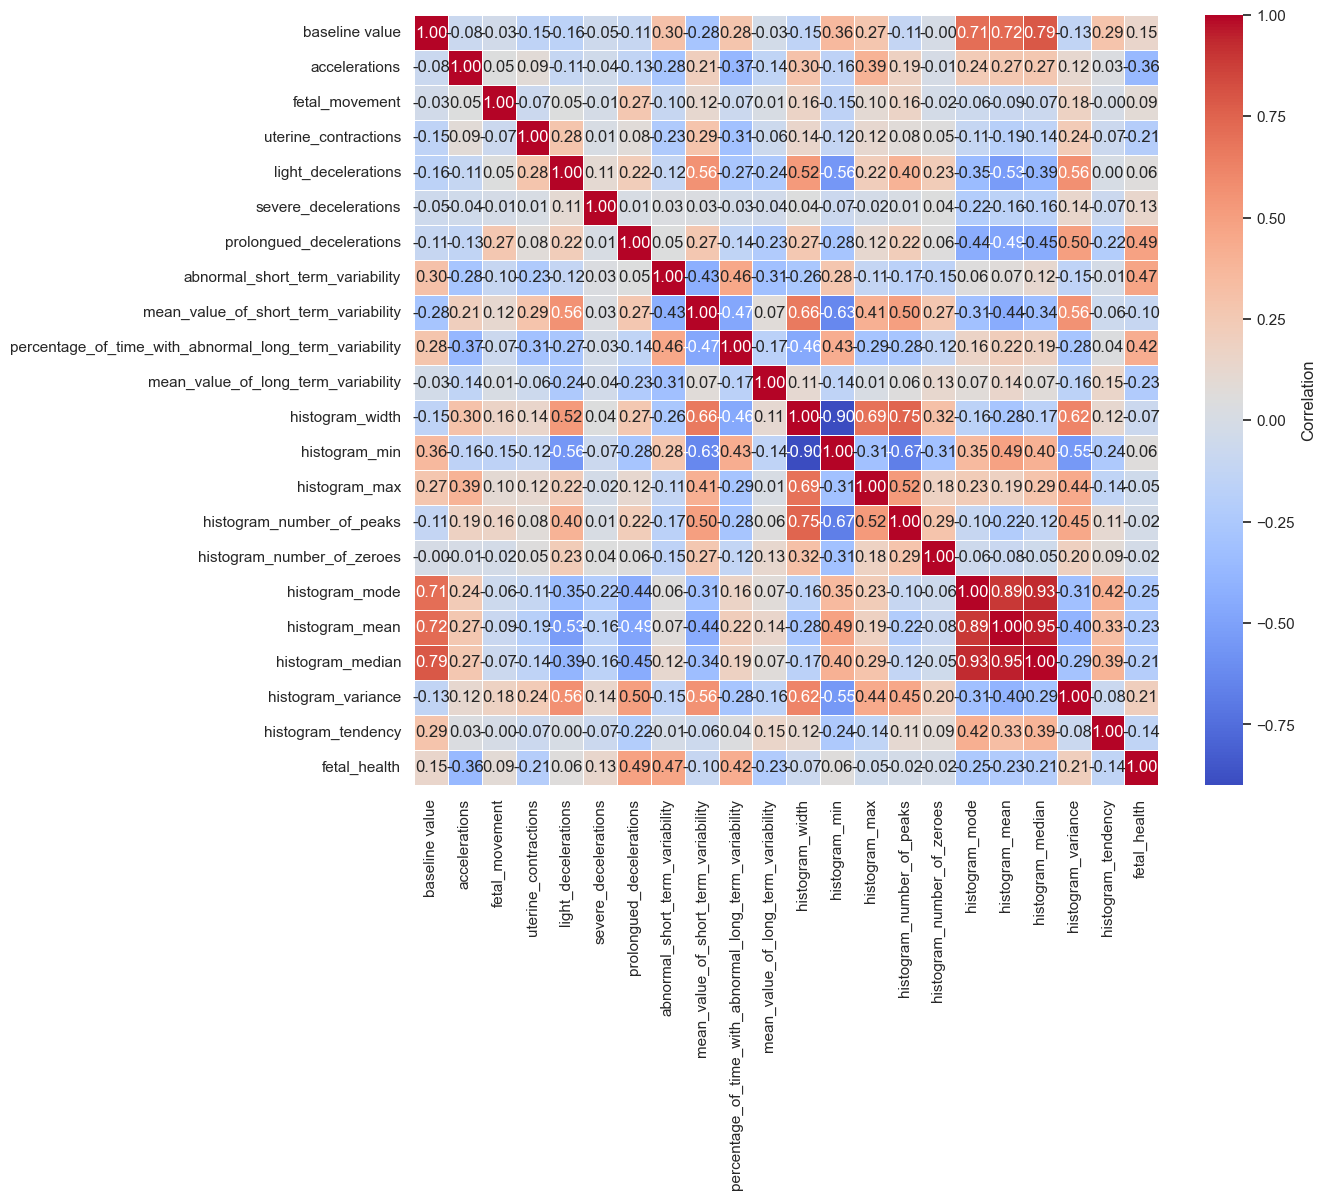

In [176]:
display(df.describe().T)

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', 
          linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.show()

In [177]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
z_scores = np.abs(stats.zscore(df[numeric_cols]))


In [178]:
#OUTLIER DETECTION
z = np.abs(stats.zscore(df[numeric_cols]))
outlier_counts = (z>3).sum()
print('Outlier counts per numeric column (z>3):')
print(outlier_counts[outlier_counts>0])

Outlier counts per numeric column (z>3):
[525]


In [179]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = df.drop(columns=['fetal_health'])
y = df['fetal_health']

  #Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (1690, 21) Test shape: (423, 21)


In [180]:
import joblib
import os

In [181]:

output_dir = '/mnt/user-data/outputs'
os.makedirs(output_dir, exist_ok=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, '/mnt/user-data/outputs/scaler.joblib')
print('Scaler saved to /mnt/data/model_output/scaler.joblib')

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

Scaler saved to /mnt/data/model_output/scaler.joblib


In [182]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
import os

output_dir = '/mnt/user-data/outputs'
os.makedirs(output_dir, exist_ok=True)

Smote

In [183]:
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train_scaled, y_train)
X_train_balanced = pd.DataFrame(X_train_balanced, columns=X_train_scaled.columns)
print(f"✓ Data balanced: {len(X_train_balanced)} samples\n")

✓ Data balanced: 3948 samples



select features

In [184]:
temp_model = RandomForestClassifier(n_estimators=100, random_state=42)
temp_model.fit(X_train_balanced, y_train_balanced)

feature_importance = pd.DataFrame({
    'Feature': X_train_balanced.columns,
    'Importance': temp_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Features:")
print(feature_importance.head(10))

selected_features = feature_importance.head(10)['Feature'].tolist()
X_train_selected = X_train_balanced[selected_features]
X_test_selected = X_test_scaled[selected_features]
print(f"✓ Selected {len(selected_features)} features\n")


Top 10 Features:
                                              Feature  Importance
7                     abnormal_short_term_variability    0.144348
9   percentage_of_time_with_abnormal_long_term_var...    0.119286
17                                     histogram_mean    0.099629
18                                   histogram_median    0.079086
8                mean_value_of_short_term_variability    0.076706
1                                       accelerations    0.073341
16                                     histogram_mode    0.060561
6                            prolongued_decelerations    0.054421
10                mean_value_of_long_term_variability    0.053269
0                                      baseline value    0.046760
✓ Selected 10 features



Train Models

In [185]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    print(f'\nTraining {name}...')
    model.fit(X_train_selected, y_train_balanced)
    trained_models[name] = model
    
    preds = model.predict(X_test_selected)
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')

    print(f"  Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

print("STEP 4: COMPARE MODELS")

results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"\n✓ Best Model: {best_model_name}")
print(f"  F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")



Training Logistic Regression...
  Accuracy: 0.8700, Precision: 0.8926, Recall: 0.8700, F1: 0.8776

Training Random Forest...
  Accuracy: 0.9338, Precision: 0.9313, Recall: 0.9338, F1: 0.9319

Training Gradient Boosting...
  Accuracy: 0.9409, Precision: 0.9406, Recall: 0.9409, F1: 0.9407
STEP 4: COMPARE MODELS


,Model,Accuracy,Precision,Recall,F1-Score
2,Gradient Boosting,0.940898,0.940558,0.940898,0.940696
1,Random Forest,0.933806,0.931297,0.933806,0.931869
0,Logistic Regression,0.869976,0.892571,0.869976,0.877602



✓ Best Model: Gradient Boosting
  F1-Score: 0.9407


Evaluate best model

In [186]:
preds = best_model.predict(X_test_selected)
y_proba = best_model.predict_proba(X_test_selected)

Confusion Matrix

<Figure size 600x500 with 0 Axes>

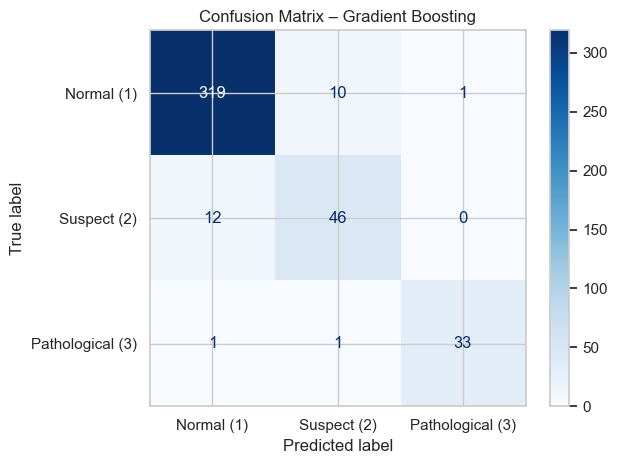

In [187]:
cm = confusion_matrix(y_test, preds, labels=[1,2,3])
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (1)', 'Suspect (2)', 'Pathological (3)'])
plt.figure(figsize=(6,5))
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix – {best_model_name}')
plt.tight_layout()
plt.show()

ROC-AUC Curves

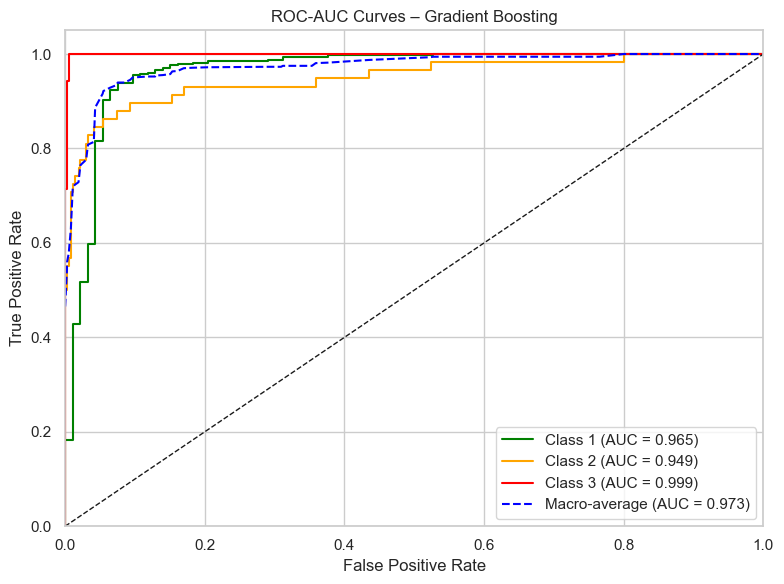


AUC Scores:
  Class 1 (Normal): 0.9648
  Class 2 (Suspect): 0.9493
  Class 3 (Pathological): 0.9991
  Macro-average: 0.9725


In [188]:
y_test_bin = label_binarize(y_test, classes=[1,2,3])
n_classes = y_test_bin.shape[1]

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
roc_auc["macro"] = auc(all_fpr, mean_tpr)

plt.figure(figsize=(8,6))
colors = ['green', 'orange', 'red']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, label=f'Class {i+1} (AUC = {roc_auc[i]:.3f})')

plt.plot(all_fpr, mean_tpr, color='blue', linestyle='--', label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-AUC Curves – {best_model_name}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\nAUC Scores:")
for i in range(n_classes):
    class_names = ['Normal', 'Suspect', 'Pathological']
    print(f"  Class {i+1} ({class_names[i]}): {roc_auc[i]:.4f}")
print(f"  Macro-average: {roc_auc['macro']:.4f}")


SAVE BEST MODEL

In [189]:
joblib.dump(best_model, os.path.join(output_dir, 'best_model.joblib'))
joblib.dump(selected_features, os.path.join(output_dir, 'selected_features.joblib'))
joblib.dump(scaler, os.path.join(output_dir, 'scaler.joblib'))

results_df.to_csv(os.path.join(output_dir, 'model_results.csv'), index=False)

print(f"✓ Best model saved")
print(f"✓ Selected features saved")
print(f"✓ Scaler saved")
print(f"✓ Results saved to CSV")

print(f"\nBest Model: {best_model_name}")
print(f"F1-Score: {results_df.iloc[0]['F1-Score']:.4f}")
print(f"Features Used: {len(selected_features)}")
print(f"\nFiles saved to: {output_dir}")

✓ Best model saved
✓ Selected features saved
✓ Scaler saved
✓ Results saved to CSV

Best Model: Gradient Boosting
F1-Score: 0.9407
Features Used: 10

Files saved to: /mnt/user-data/outputs
